## Financial Trend Analysis of S&P 500 Stocks

## Objective

Analyze stock performance over time and identify top-performing companies based on returns.

In [17]:
import pandas as pd
import numpy as np
df = pd.read_csv('all_stocks_5yr.csv')
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 33.1 MB


In [19]:
df.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


In [20]:
df.isna().sum().sort_values(ascending=False)

open      11
high       8
low        8
date       0
close      0
volume     0
Name       0
dtype: int64

## Data Cleaning

-Converted data column to datetime
-Removed missing values

In [21]:
df['date'] = pd.to_datetime(df['date'])

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    619040 non-null  datetime64[us]
 1   open    619029 non-null  float64       
 2   high    619032 non-null  float64       
 3   low     619032 non-null  float64       
 4   close   619040 non-null  float64       
 5   volume  619040 non-null  int64         
 6   Name    619040 non-null  str           
dtypes: datetime64[us](1), float64(4), int64(1), str(1)
memory usage: 33.1 MB


In [23]:
df = df.dropna()

In [24]:
df.isna().sum()

date      0
open      0
high      0
low       0
close     0
volume    0
Name      0
dtype: int64

In [25]:
df['Name'].unique()

<StringArray>
[ 'AAL', 'AAPL',  'AAP', 'ABBV',  'ABC',  'ABT',  'ACN', 'ADBE',  'ADI',
  'ADM',
 ...
 'XLNX',   'XL',  'XOM', 'XRAY',  'XRX',  'XYL',  'YUM',  'ZBH', 'ZION',
  'ZTS']
Length: 505, dtype: str

## Analysis
Visualized individual stock trends, compared Apple and American Airlines, Normalized stock prices, Calculated returns

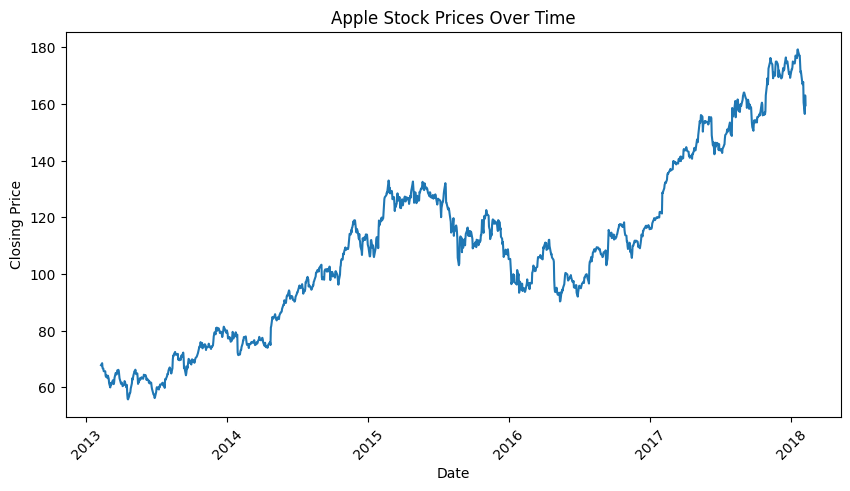

In [26]:
import matplotlib.pyplot as plt

aapl = df[df['Name'] == 'AAPL']

plt.figure(figsize=(10,5))
plt.plot(aapl['date'], aapl['close'])
plt.title("Apple Stock Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.show()

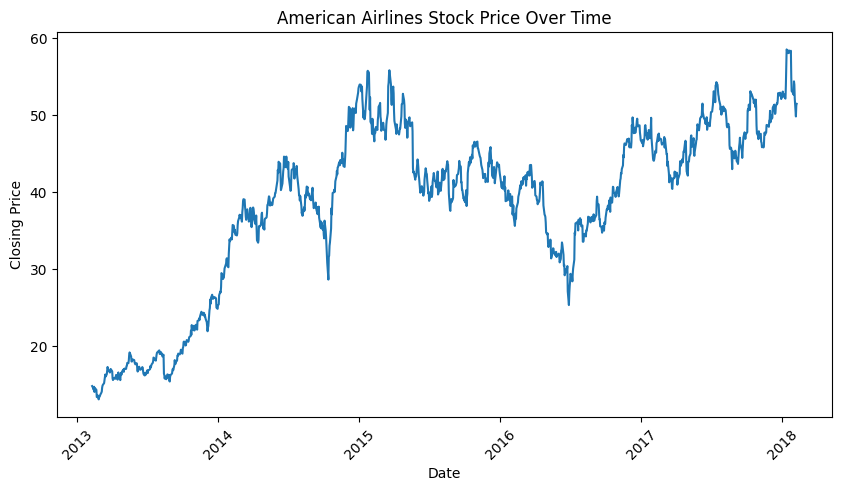

In [27]:
aal = df[df['Name'] == 'AAL']

plt.figure(figsize=(10,5))
plt.plot(aal['date'], aal['close'])
plt.title("American Airlines Stock Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.xticks(rotation=45)
plt.show()

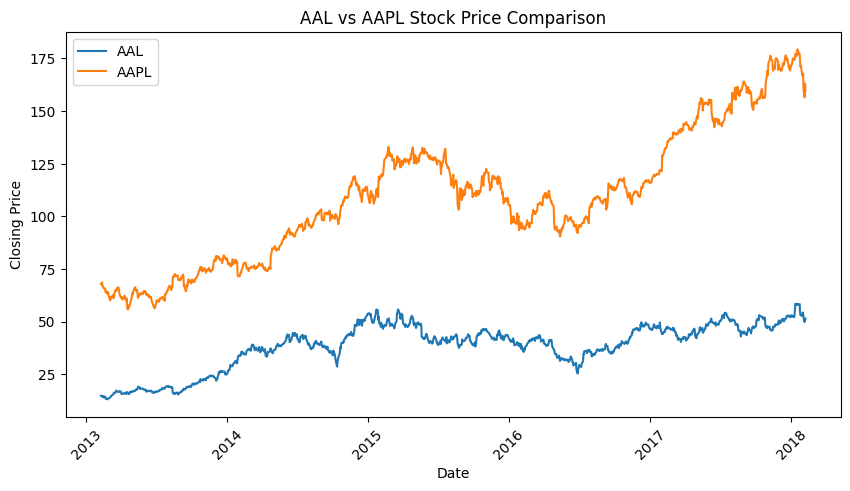

In [28]:
aal = df[df['Name'] == 'AAL']
aapl = df[df['Name'] == 'AAPL']

plt.figure(figsize=(10,5))
plt.plot(aal['date'], aal['close'], label='AAL')
plt.plot(aapl['date'], aapl['close'], label='AAPL')

plt.title("AAL vs AAPL Stock Price Comparison")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

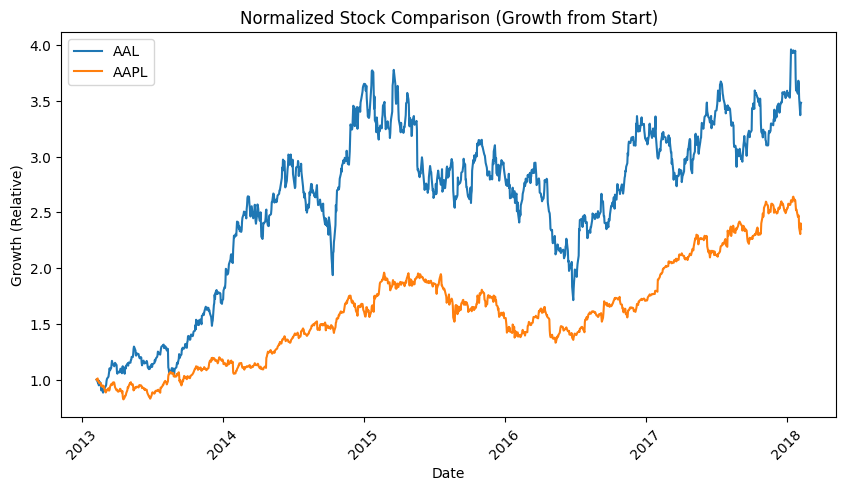

In [29]:
aal = df[df['Name'] == 'AAL']
aapl = df[df['Name'] == 'AAPL']

aal_norm = aal['close'] / aal['close'].iloc[0]
aapl_norm = aapl['close'] / aapl['close'].iloc[0]

plt.figure(figsize=(10,5))
plt.plot(aal['date'], aal_norm, label='AAL')
plt.plot(aapl['date'], aapl_norm, label='AAPL')

plt.title("Normalized Stock Comparison (Growth from Start)")
plt.xlabel("Date")
plt.ylabel("Growth (Relative)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

In [30]:
aal_return = (aal['close'].iloc[-1] / aal['close'].iloc[0] - 1) * 100
aapl_return = (aapl['close'].iloc[-1] / aapl['close'].iloc[0] - 1) * 100

print("AAL Return:", round(aal_return, 2), "%")
print("AAPL Return:", round(aapl_return, 2), "%")

AAL Return: 248.47 %
AAPL Return: 135.12 %


In [31]:
returns = (
    df.sort_values(['Name', 'date'])
    .groupby('Name')['close'].agg(lambda x: (x.iloc[-1] / x.iloc[0] - 1) * 100)
)
top_stock = returns.sort_values(ascending=False).head(5)
print(top_stock)

Name
NVDA    1749.636217
NFLX     923.332096
ALGN     615.948671
EA       608.405296
STZ      572.370487
Name: close, dtype: float64


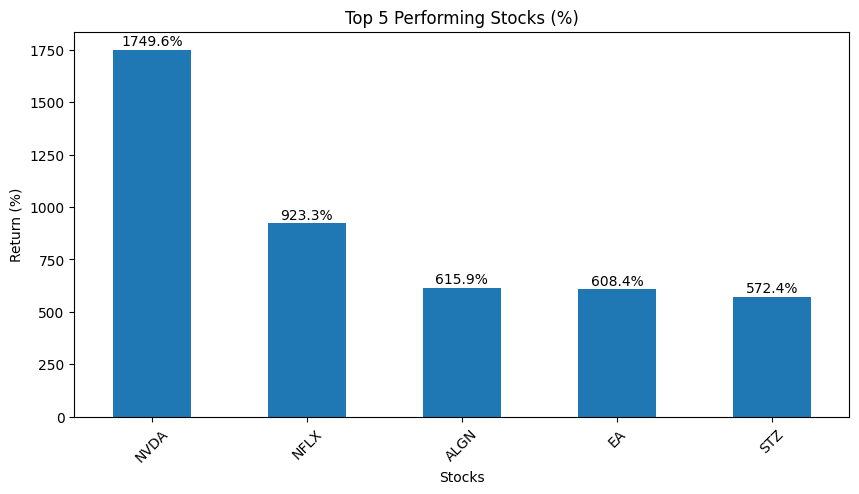

In [32]:
top_stock.plot(kind='bar', figsize=(10,5))
plt.title("Top 5 Performing Stocks (%)")
plt.ylabel("Return (%)")
plt.xlabel("Stocks")
plt.xticks(rotation=45)

for i, v in enumerate(top_stock):
    plt.text(i, v + 20, f"{round(v,1)}%", ha='center')

plt.show()

## Key Findings

NVIDIA (1749%) and Netflix (923%) were top performers, Technology stocks dominated growth, Some stocks showed higher volatility vs stability 